In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('drugs.csv')
df.head(2)

,generic_name,brand_name,drug_class,indication,dosage,renal_adjustment,renal_adjustment_dose,administration,preparation_for_administration,storage_stability
0,Ampicillin,NaN,Antibiotic,Endocarditis,treatment 200 to 300 mg/kg/day divided every ...,yes,GFR 30 to 50 mL/minute/1.73 m2: 35 to 50 mg/kg...,IV push: Doses ≤500 mg should be administered ...,Reconstitute vial with the following amounts o...,NaN
1,Ampicillin,NaN,Antibiotic,Endocarditis,treatment 200 to 300 mg/kg/day divided every ...,yes,GFR 10 to 29 mL/minute/1.73 m2: 35 to 50 mg/k...,IV push: Doses ≤500 mg should be administered ...,Reconstitute vial with the following amounts o...,NaN


In [23]:
df.describe(include='all')

,generic_name,drug_class,indication,dosage,renal_adjustment,renal_adjustment_dose,administration,preparation_for_administration,indication_group
count,57,57,57,57,57,57,57,57,57
unique,10,4,21,25,2,38,13,13,2
top,Ampicillin,Antibiotic,Endocarditis,"acute retinal necrosis, treatment (patients w...",yes,CrCl 5 to 14 mL/minute/1.73 m2: Administer eve...,IV push: Doses ≤500 mg should be administered ...,Reconstitute vial with the following amounts o...,Other
freq,15,43,9,4,48,4,12,12,44


In [3]:
def chk_dtypes(df):
    dtypes = df.dtypes
    uniq = df.nunique()
    return pd.DataFrame({'dtypes':dtypes , 'unique': uniq}).T
chk_dtypes(df)

,generic_name,brand_name,drug_class,indication,dosage,renal_adjustment,renal_adjustment_dose,administration,preparation_for_administration,storage_stability
dtypes,object,object,object,object,object,object,object,object,object,object
unique,10,2,4,21,25,4,38,13,13,2


In [4]:
def chk_null(df):
    null = df.isnull().sum()
    ratio = null / df.shape[0] *100
    return pd.DataFrame({'null': null,'ratio':ratio}).T
chk_null(df)

,generic_name,brand_name,drug_class,indication,dosage,renal_adjustment,renal_adjustment_dose,administration,preparation_for_administration,storage_stability
null,0.0,50.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.000000
ratio,0.0,87.719298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,92.982456


In [6]:
df = df.dropna(axis=1)
chk_null(df)

,generic_name,drug_class,indication,dosage,renal_adjustment,renal_adjustment_dose,administration,preparation_for_administration
null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


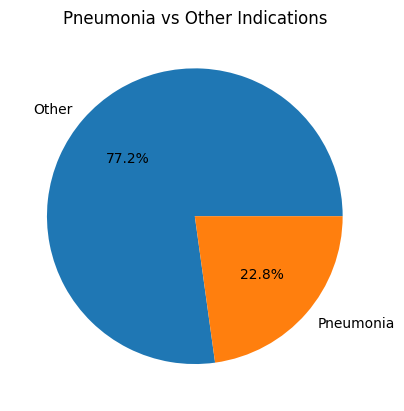

In [21]:
df['indication_group'] = df['indication'].apply(
    lambda x: 'Pneumonia' if 'pneumonia' in x.lower() else 'Other'
)

counts = df['indication_group'].value_counts()

plt.figure()
counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Pneumonia vs Other Indications")
plt.ylabel("")
plt.show()

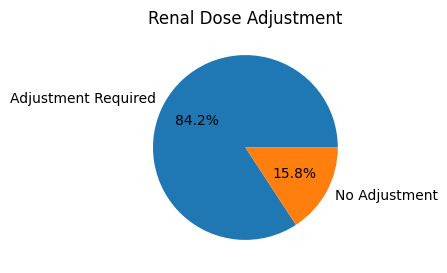

In [19]:
adjustment_counts = df['renal_adjustment'].value_counts()

adjustment_counts.index = ['Adjustment Required','No Adjustment']

plt.figure(figsize=(3,3))
adjustment_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Renal Dose Adjustment")
plt.ylabel("")
plt.show()

<Axes: xlabel='renal_adjustment', ylabel='indication'>

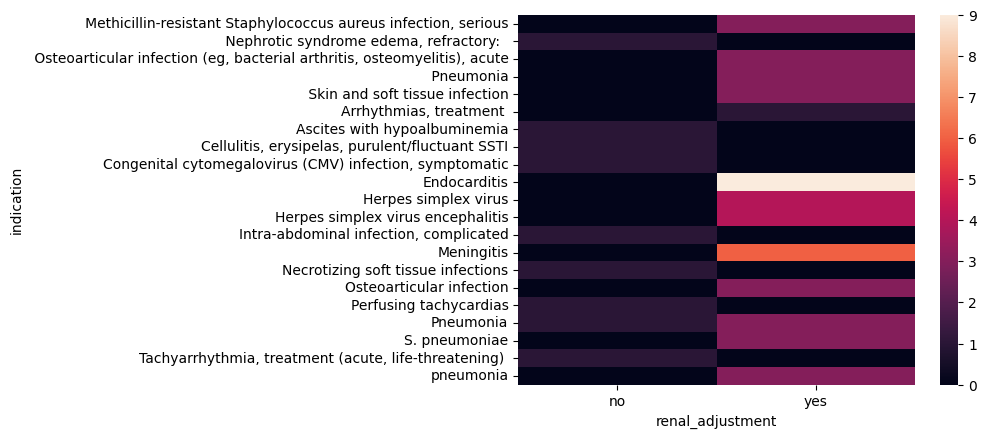

In [27]:
import seaborn as sns

sns.heatmap(pd.crosstab(df['indication'], df['renal_adjustment']))

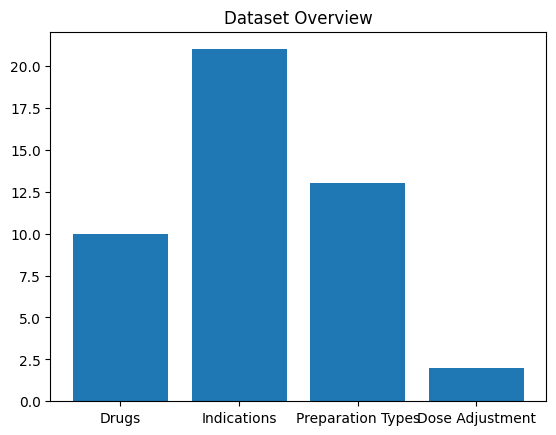

In [30]:
overview = {
    "Drugs": df['generic_name'].nunique(),
    "Indications": df['indication'].nunique(),
    "Preparation Types": df['administration'].nunique(),
    "Dose Adjustment": df['renal_adjustment'].nunique()
}

plt.figure()
plt.bar(overview.keys(), overview.values())
plt.title("Dataset Overview")
plt.show()